# STEP 0: INSTALL AND IMPORT LIBRARIES
## Install necessary libraries from Hugging Face, scikit-learn, etc.

In [ ]:
!pip install wandb transformers datasets scikit-learn scikit-multilearn emoji torch --quiet

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import emoji
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel, Trainer, TrainingArguments
from datasets import Dataset
from skmultilearn.model_selection import iterative_train_test_split
from dataclasses import dataclass
from transformers.tokenization_utils_base import PaddingStrategy, PreTrainedTokenizerBase
from typing import Any, Dict, List, Optional, Union
import random

In [ ]:
# Fungsi untuk mengunci Random Seed
def set_seed(seed_value=42):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    torch.cuda.manual_seed_all(seed_value)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed_value)

# Set seed global
SEED = 42
set_seed(SEED)
print(f"Random seed telah dikunci ke: {SEED}")

# STEP 1: LOAD DATASET
## Ensure 'dataset.csv' is available in your environment.

In [ ]:
try:
    df = pd.read_csv('https://raw.githubusercontent.com/gikirima/TEA-emoji/refs/heads/main/dataset_emoji_only.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: not found. Please upload the file.")
    exit()

Dataset loaded successfully.


# STEP 2: EMOJI EXTRACTION & VOCABULARY CREATION
## Scan the dataset to build a vocabulary of unique emojis.

In [ ]:
print("\nScanning dataset for unique emojis...")
unique_emojis = set()
for text in df['text'].dropna():
    text_str = str(text)
    for character in text_str:
        if emoji.is_emoji(character):
            unique_emojis.add(character)

# Create a mapping from emoji to integer ID. ID 0 is reserved for padding.
emoji_list = sorted(list(unique_emojis))
emoji_to_id = {em: i for i, em in enumerate(emoji_list, 1)}
emoji_to_id['<PAD>'] = 0
id_to_emoji = {i: em for em, i in emoji_to_id.items()}
EMOJI_VOCAB_SIZE = len(emoji_to_id)
EMOJI_PAD_ID = emoji_to_id['<PAD>']

print(f"Found {len(unique_emojis)} unique emojis.")
print(f"Emoji vocabulary size (including <PAD>): {EMOJI_VOCAB_SIZE}")


Scanning dataset for unique emojis...
Found 1040 unique emojis.
Emoji vocabulary size (including <PAD>): 1041


# STEP 3: DEFINE CUSTOM MODEL (LATE FUSION)
## This model architecture processes text and emojis in separate branches.

In [ ]:
class BertEmojiLateFusionModel(nn.Module):
    """
    Custom model using a Late Fusion architecture.

    It has two independent branches:
    1. Text Branch: IndoBERT processes the raw text to produce text-based logits.
    2. Emoji Branch: A separate MLP processes pooled emoji embeddings to produce
       emoji-based logits.

    The final logits are the sum of the logits from both branches.
    """
    def __init__(self, model_name, num_labels, emoji_vocab_size, emoji_emb_dim=256, dropout_rate=0.1):
        super().__init__()
        self.num_labels = num_labels

        # 1. Text Branch: Base BERT model
        self.bert = AutoModel.from_pretrained(model_name)
        bert_hidden_size = self.bert.config.hidden_size

        # 2. Emoji Branch: Embedding and processing layers
        self.emoji_embeddings = nn.Embedding(emoji_vocab_size, emoji_emb_dim, padding_idx=EMOJI_PAD_ID)
        self.emoji_classifier = nn.Sequential(
            nn.Linear(emoji_emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_labels)
        )

        # 3. Text Branch: Classifier head
        self.text_classifier = nn.Sequential(
            nn.Linear(bert_hidden_size, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, num_labels)
        )

        # Compatibility with Hugging Face Trainer
        self.config = self.bert.config
        self.config.problem_type = "multi_label_classification"

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
        emoji_ids: torch.Tensor,
        labels: Optional[torch.Tensor] = None
    ):
        # --- 1. Text Branch ---
        bert_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_text = bert_outputs.last_hidden_state[:, 0, :] # Shape: [B, H]
        logits_text = self.text_classifier(cls_text) # Shape: [B, num_labels]

        # --- 2. Emoji Branch ---
        emoji_embs = self.emoji_embeddings(emoji_ids) # Shape: [B, E, Emb_Dim]

        # Create a mask to ignore padding tokens during mean pooling
        emoji_mask = (emoji_ids != EMOJI_PAD_ID).unsqueeze(-1).float()
        # Sum embeddings and count non-pad emojis
        sum_embs = (emoji_embs * emoji_mask).sum(dim=1)
        count_embs = emoji_mask.sum(dim=1)
        # Calculate safe mean (avoid division by zero)
        pooled_emojis = sum_embs / count_embs.clamp(min=1e-9) # Shape: [B, Emb_Dim]

        logits_emoji = self.emoji_classifier(pooled_emojis) # Shape: [B, num_labels]

        # --- 3. Fusion ---
        # Combine the logits from both branches
        logits = (logits_text + logits_emoji) / 2

        # --- 4. Calculate loss if labels are provided ---
        loss = None
        if labels is not None:
            loss_fct = nn.BCEWithLogitsLoss()
            loss = loss_fct(logits, labels.float())

        return (loss, logits) if loss is not None else (logits,)

# --- Initialize Model and Tokenizer ---
model_name = "indobenchmark/indobert-base-p1"
label_columns = ['joy', 'trust', 'fear', 'surprise', 'sadness', 'disgust', 'anger', 'anticipation']
num_labels = len(label_columns)
EMOJI_EMBEDDING_DIM = 128 # INI HYPERPARAMETER YANG BISA DIUBAH

print(f"\nLoading tokenizer '{model_name}'...")
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Initializing custom model 'BertEmojiLateFusionModel'...")
model = BertEmojiLateFusionModel(
    model_name=model_name,
    num_labels=num_labels,
    emoji_vocab_size=EMOJI_VOCAB_SIZE,
    emoji_emb_dim=EMOJI_EMBEDDING_DIM
)
print("Model and tokenizer are ready.")


Loading tokenizer 'indobenchmark/indobert-base-p1'...
Initializing custom model 'BertEmojiLateFusionModel'...
Model and tokenizer are ready.


# STEP 4: PREPARE DATASET FOR HUGGING FACE
## Split data into training, validation, and test sets.

In [ ]:
print("\nSplitting dataset using iterative_train_test_split...")
X = df['text'].to_numpy().reshape(-1, 1)
y = df[label_columns].to_numpy()

# Stratified split for multi-label data
X_train_val, y_train_val, X_test, y_test = iterative_train_test_split(X, y, test_size=0.2)
X_train, y_train, X_val, y_val = iterative_train_test_split(X_train_val, y_train_val, test_size=0.2)

df_train = pd.DataFrame(X_train.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_train[col] = y_train[:, i]

df_val = pd.DataFrame(X_val.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_val[col] = y_val[:, i]

df_test = pd.DataFrame(X_test.flatten(), columns=['text'])
for i, col in enumerate(label_columns): df_test[col] = y_test[:, i]

print("\nConverting DataFrames to Hugging Face Datasets...")
train_dataset_hf = Dataset.from_pandas(df_train)
eval_dataset_hf = Dataset.from_pandas(df_val)
test_dataset_hf = Dataset.from_pandas(df_test)

# --- Preprocessing Function ---
def preprocess_data(examples):
    # 1. Tokenize text for BERT
    tokenized_output = tokenizer(
        examples["text"], padding=False, truncation=True, max_length=128
    )

    # 2. Extract and map emojis to their IDs
    all_emoji_ids = []
    texts = [str(t) for t in examples["text"]]
    for text in texts:
        ids = [emoji_to_id.get(char) for char in text if emoji.is_emoji(char) and char in emoji_to_id]
        ids = [id for id in ids if id is not None]
        if not ids:
            ids = [EMOJI_PAD_ID] # Use a single PAD token if no emojis are present
        all_emoji_ids.append(ids)

    # 3. Format labels
    labels = [[float(examples[label][i]) for label in label_columns] for i in range(len(texts))]

    tokenized_output["emoji_ids"] = all_emoji_ids
    tokenized_output["labels"] = labels
    return tokenized_output

print("\nTokenizing text and extracting emojis for all datasets...")
train_dataset = train_dataset_hf.map(preprocess_data, batched=True, remove_columns=train_dataset_hf.column_names)
eval_dataset = eval_dataset_hf.map(preprocess_data, batched=True, remove_columns=eval_dataset_hf.column_names)
test_dataset = test_dataset_hf.map(preprocess_data, batched=True, remove_columns=test_dataset_hf.column_names)

print("\n--- Data Splitting and Preprocessing Complete ---")
print(f"Training data count: {len(train_dataset)}")
print(f"Validation data count: {len(eval_dataset)}")
print(f"Test data count: {len(test_dataset)}")


Splitting dataset using iterative_train_test_split...

Converting DataFrames to Hugging Face Datasets...

Tokenizing text and extracting emojis for all datasets...


Map:   0%|          | 0/89312 [00:00<?, ? examples/s]

Map:   0%|          | 0/22090 [00:00<?, ? examples/s]

Map:   0%|          | 0/28012 [00:00<?, ? examples/s]


--- Data Splitting and Preprocessing Complete ---
Training data count: 89312
Validation data count: 22090
Test data count: 28012


In [ ]:
# --- HITUNG CLASS WEIGHTS (Penanganan Imbalance) ---

# Ambil array label (0 atau 1) dari DataFrame df_train
labels_array = df_train[label_columns].to_numpy()

# Hitung jumlah sampel positif dan negatif per label
num_positives = labels_array.sum(axis=0)
num_negatives = labels_array.shape[0] - num_positives

# Rumus: pos_weight = jumlah_negatif / jumlah_positif
# Ditambah epsilon (1e-5) agar aman dari error pembagian nol
pos_weights_tensor = torch.tensor((num_negatives / (num_positives + 1e-5)), dtype=torch.float)

# Pindahkan ke GPU agar kompatibel saat training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pos_weights_tensor = pos_weights_tensor.to(device)

print("\nClass Weights (pos_weight) berhasil dihitung:")
for label, weight in zip(label_columns, pos_weights_tensor):
    print(f"- {label}: {weight.item():.4f}")

# STEP 4.5: CREATE CUSTOM DATA COLLATOR
## This collator handles dynamic padding for both text and emoji ID sequences.

In [ ]:
@dataclass
class CustomDataCollator:
    tokenizer: PreTrainedTokenizerBase
    padding: Union[bool, str, PaddingStrategy] = True
    max_length: Optional[int] = None
    pad_to_multiple_of: Optional[int] = None

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        labels = [feature.pop("labels") for feature in features]
        emoji_ids = [feature.pop("emoji_ids") for feature in features]

        # Use the tokenizer's default padding for text-based inputs
        batch = self.tokenizer.pad(
            features,
            padding=self.padding,
            max_length=self.max_length,
            pad_to_multiple_of=self.pad_to_multiple_of,
            return_tensors="pt",
        )

        # Manually pad the emoji_ids sequences
        max_emoji_len = max(len(ids) for ids in emoji_ids)
        padded_emoji_ids = [ids + [EMOJI_PAD_ID] * (max_emoji_len - len(ids)) for ids in emoji_ids]

        # Add the padded data back to the batch
        batch["labels"] = torch.tensor(labels, dtype=torch.float)
        batch["emoji_ids"] = torch.tensor(padded_emoji_ids, dtype=torch.long)

        return batch

data_collator = CustomDataCollator(tokenizer=tokenizer)

# STEP 5: DEFINE EVALUATION METRICS
## Function to compute performance metrics for multi-label classification.

In [ ]:
def compute_metrics(p):
    logits, labels = p
    preds_proba = torch.sigmoid(torch.tensor(logits))
    # Use a 0.5 threshold to binarize predictions
    preds = (preds_proba > 0.5).int().numpy()
    labels = labels.astype(int)

    f1_macro = f1_score(labels, preds, average='macro', zero_division=0)
    f1_micro = f1_score(labels, preds, average='micro', zero_division=0)
    precision_micro = precision_score(labels, preds, average='micro', zero_division=0)
    recall_micro = recall_score(labels, preds, average='micro', zero_division=0)

    return {
        'f1_macro': f1_macro,
        'f1_micro': f1_micro,
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'accuracy': accuracy_score(labels, preds), # Exact match ratio
    }

# STEP 6: CONFIGURE AND RUN TRAINING
## Set up training arguments and initialize the Hugging Face Trainer.

In [ ]:
# 1. Custom Trainer Khusus untuk Model Late Fusion (Tuple Output)
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        
        # [PENTING] Model Late Fusion mengembalikan tuple (loss, logits)
        # Kita harus ambil logits dari indeks ke-1
        if isinstance(outputs, tuple):
            logits = outputs[1]
        elif hasattr(outputs, 'logits'):
            logits = outputs.logits
        else:
            logits = outputs
            
        # Menggunakan BCEWithLogitsLoss dengan pos_weight
        loss_fct = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)
        loss = loss_fct(logits, labels.float())
        
        return (loss, outputs) if return_outputs else loss

In [ ]:
# WANDB integration for experiment tracking.
try:
    from google.colab import userdata
    wandb_api_key = userdata.get('WANDB_API_KEY')
    import wandb
    if wandb_api_key:
        wandb.login(key=wandb_api_key)
        print("WANDB login successful.")
        wandb.init(
            project="LF_Model_Weighted_Training",
            name="Training_8",
        )
    else:
        print("WANDB_API key not found. Skipping WANDB logging.")
        report_to = "none"
except (ImportError, KeyError):
    print("Not in Colab or WANDB key not set. Skipping WANDB logging.")
    report_to = "none"


training_args = TrainingArguments(
    output_dir="./results_late_fusion",
    eval_strategy="steps",
    save_strategy="steps",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=250,
    eval_steps=1500,
    save_steps=1500,
    save_total_limit=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    learning_rate=5e-5,
    warmup_steps=500,
    weight_decay=0.01,
    fp16=True, # Requires a GPU with Tensor Cores
    report_to="wandb",
    seed=SEED,
    data_seed=SEED
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("\nMemulai proses fine-tuning model (Late Fusion) dengan Class Weights & Seed...")
trainer.train()

print("\nPelatihan selesai.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


WANDB login successful.


/tmp/ipython-input-2770862899.py:43: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Starting model fine-tuning with Late Fusion...


Step,Training Loss,Validation Loss,F1 Macro,F1 Micro,Precision Micro,Recall Micro,Accuracy
1500,0.274300,0.254055,0.531870,0.777689,0.780531,0.774868,0.494296
3000,0.241800,0.226326,0.588392,0.805465,0.836319,0.776806,0.532368
4500,0.231200,0.217705,0.634887,0.808965,0.810145,0.807790,0.535582
6000,0.196900,0.203091,0.676690,0.825175,0.835859,0.814761,0.566591
7500,0.193200,0.209439,0.657771,0.820547,0.821489,0.819606,0.547261
9000,0.190300,0.200855,0.683870,0.825892,0.829059,0.822750,0.557266
10500,0.186300,0.199822,0.671893,0.823358,0.844158,0.803559,0.554821
12000,0.143200,0.213128,0.684455,0.825203,0.817773,0.832770,0.560706
13500,0.145000,0.206372,0.695373,0.828694,0.827551,0.829840,0.566003
15000,0.139600,0.213833,0.696249,0.825676,0.814161,0.837520,0.558941



Training complete.


# STEP 7: FINAL EVALUATION
## Evaluate the best model on the held-out test set.


Evaluating the best model on the test set...



Final Evaluation Results:
{'eval_loss': 0.21505506336688995, 'eval_f1_macro': 0.6819289442366382, 'eval_f1_micro': 0.8198389548110598, 'eval_precision_micro': 0.8179780360540245, 'eval_recall_micro': 0.8217083601407864, 'eval_accuracy': 0.55561902041982, 'eval_runtime': 27.8703, 'eval_samples_per_second': 1005.085, 'eval_steps_per_second': 62.827, 'epoch': 3.0}

Generating predictions for confusion matrix...

Creating confusion matrix plots for each label...
Confusion matrix plot saved to: ./fine_tuned_late_fusion_model/confusion_matrix.png


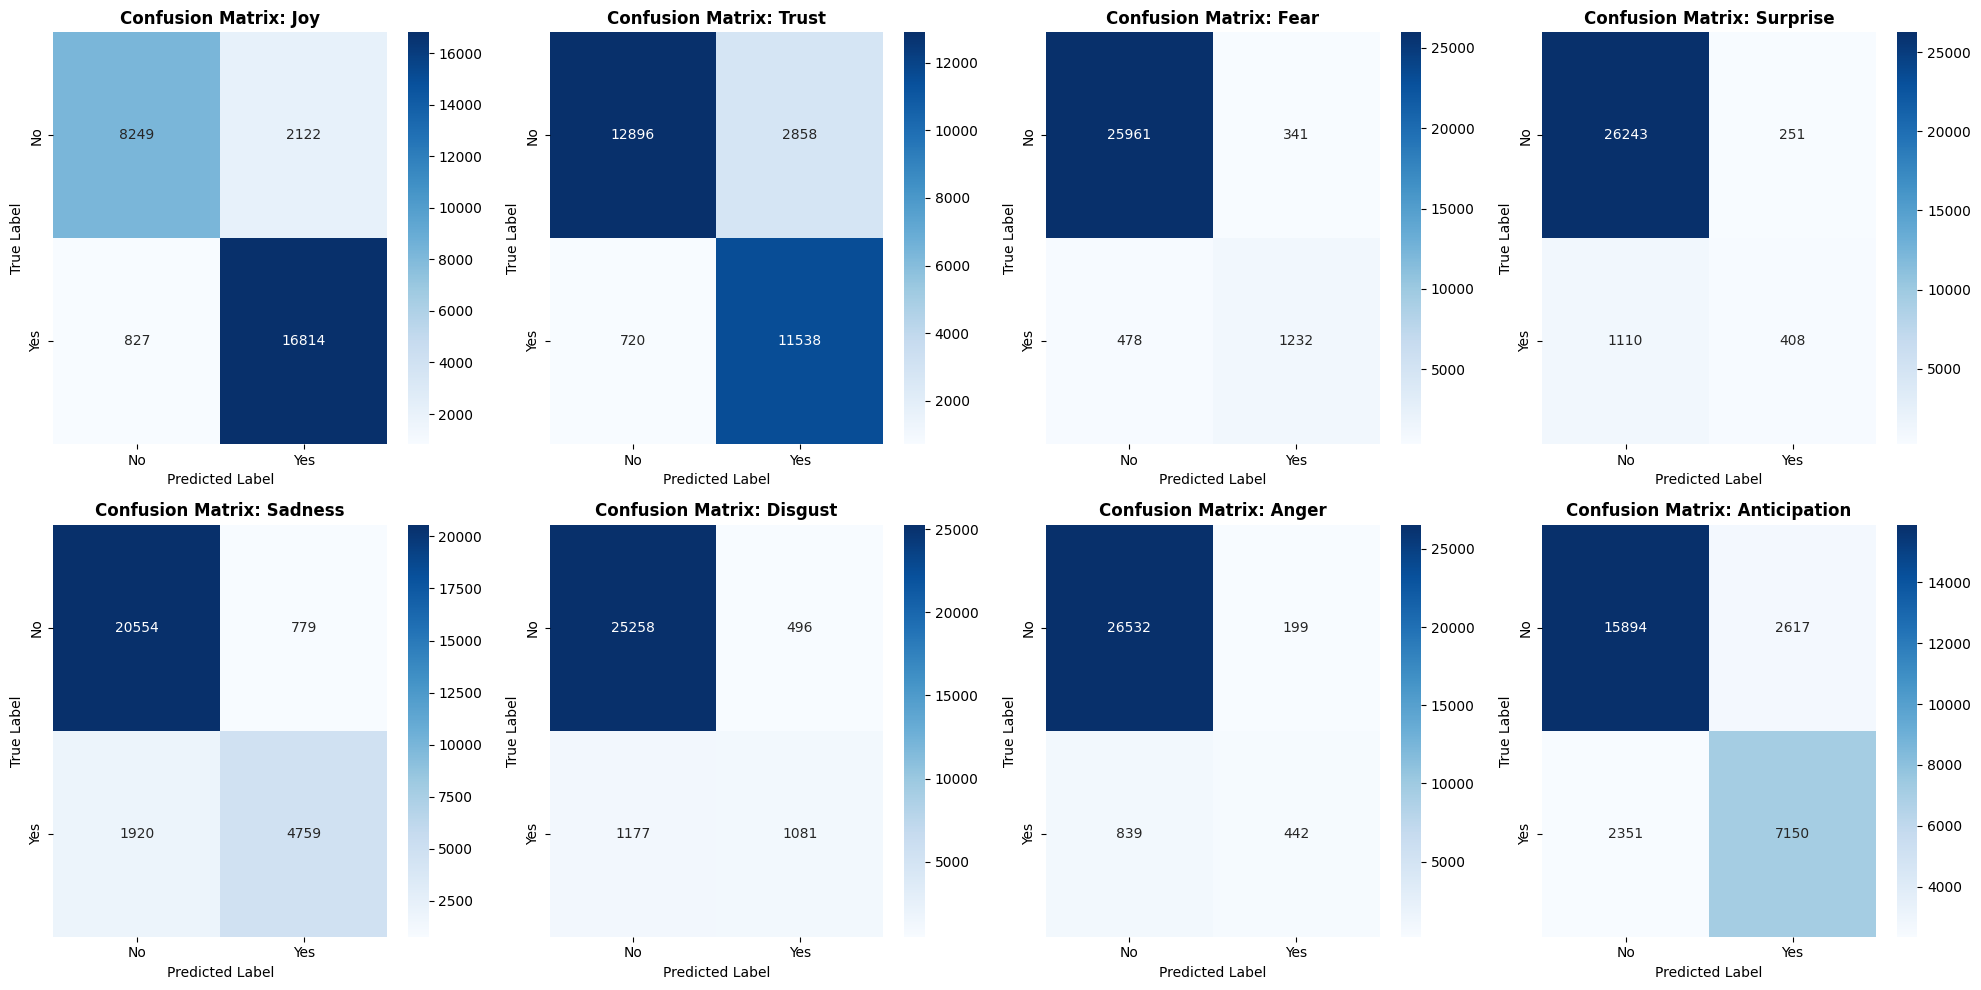

Logging artifacts to W&B...


<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n=== 1. PENCARIAN DYNAMIC THRESHOLD (MENGGUNAKAN VALIDATION SET) ===")

# Ambil prediksi mentah (logits) dari data VALIDASI
val_output = trainer.predict(eval_dataset)
val_logits = val_output.predictions
val_labels = val_output.label_ids

# Ubah logits ke probabilitas (Sigmoid)
val_probs = torch.sigmoid(torch.tensor(val_logits)).numpy()

# Cari threshold terbaik untuk SETIAP label
best_thresholds = np.full(num_labels, 0.5) 
search_range = np.arange(0.1, 0.95, 0.05) 

print("Mengoptimalkan threshold per label...")
for i in range(num_labels):
    best_f1 = 0
    best_thresh = 0.5
    for thresh in search_range:
        preds = (val_probs[:, i] > thresh).astype(int)
        current_f1 = f1_score(val_labels[:, i], preds, zero_division=0)
        
        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh
    
    best_thresholds[i] = best_thresh

# Tampilkan Threshold terpilih
thresh_df = pd.DataFrame({'Label': label_columns, 'Optimized Threshold': best_thresholds})
print(thresh_df)


print("\n=== 2. EVALUASI TEST SET (DENGAN DYNAMIC THRESHOLD) ===")

# Ambil prediksi mentah dari data TEST
test_output = trainer.predict(test_dataset)
test_probs = torch.sigmoid(torch.tensor(test_output.predictions)).numpy()
test_labels_true = test_output.label_ids

# Array untuk menyimpan prediksi final
final_test_preds = np.zeros_like(test_probs, dtype=int)

# Terapkan threshold yang sudah dioptimalkan
for i in range(num_labels):
    final_test_preds[:, i] = (test_probs[:, i] > best_thresholds[i]).astype(int)

# --- HITUNG METRIK ---

# 1. Metrik Global
global_acc = accuracy_score(test_labels_true, final_test_preds)
global_f1_macro = f1_score(test_labels_true, final_test_preds, average='macro')
global_f1_micro = f1_score(test_labels_true, final_test_preds, average='micro')

print(f"\n[Global Metrics]")
print(f"Accuracy (Exact Match): {global_acc:.4f}")
print(f"F1 Macro Average      : {global_f1_macro:.4f}")
print(f"F1 Micro Average      : {global_f1_micro:.4f}")

# 2. Metrik Per Kelas
f1_per_class = f1_score(test_labels_true, final_test_preds, average=None)
prec_per_class = precision_score(test_labels_true, final_test_preds, average=None, zero_division=0)
rec_per_class = recall_score(test_labels_true, final_test_preds, average=None, zero_division=0)

# Buat DataFrame Laporan
df_metrics = pd.DataFrame({
    'Label': label_columns,
    'Threshold': best_thresholds,
    'Precision': prec_per_class,
    'Recall': rec_per_class,
    'F1-Score': f1_per_class
})

print("\n[Detailed Metrics Per Class]")
print(df_metrics.round(4).to_string(index=False))

# 3. Tampilkan Classification Report standar
print("\n--- SKLEARN CLASSIFICATION REPORT ---")
print(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))

# --- VISUALISASI CONFUSION MATRIX ---
print("\n=== 3. VISUALISASI CONFUSION MATRIX ===")

# Siapkan grid plot
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten() 

for i, label_name in enumerate(label_columns):
    # Hitung CM menggunakan prediksi yang sudah di-threshold
    cm = confusion_matrix(
        y_true=test_labels_true[:, i], 
        y_pred=final_test_preds[:, i]
    )

    # Plot Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])

    axes[i].set_title(f"{label_name.title()} (Thresh: {best_thresholds[i]:.2f})", fontweight='bold')
    axes[i].set_xlabel('Prediksi')
    axes[i].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

# save plot to drive
# --- Generate, Save, and Log Confusion Matrix Plot ---
final_model_path = "./fine_tuned_late_fusion_model"
os.makedirs(final_model_path, exist_ok=True)
cm_plot_path = os.path.join(final_model_path, "confusion_matrices.png")
fig.savefig(cm_plot_path)
print(f"\nConfusion matrix plot saved to: {cm_plot_path}")

# simpan laporan metrik ke CSV
metrics_csv_path = os.path.join(final_model_path, "detailed_metrics_per_class.csv")
df_metrics.to_csv(metrics_csv_path, index=False)
print(f"Detailed metrics per class saved to: {metrics_csv_path}")

# simpan laporan global metrik ke TXT
global_metrics_txt_path = os.path.join(final_model_path, "global_metrics.txt")
with open(global_metrics_txt_path, 'w') as f:
    f.write(f"Global Metrics:\n")
    f.write(f"Accuracy (Exact Match): {global_acc:.4f}\n")
    f.write(f"F1 Macro Average      : {global_f1_macro:.4f}\n")
    f.write(f"F1 Micro Average      : {global_f1_micro:.4f}\n")
print(f"Global metrics saved to: {global_metrics_txt_path}")

# simpan classification report ke TXT
classification_report_txt_path = os.path.join(final_model_path, "classification_report.txt")
with open(classification_report_txt_path, 'w') as f:
    f.write(classification_report(test_labels_true, final_test_preds, target_names=label_columns, zero_division=0))
print(f"Classification report saved to: {classification_report_txt_path}")

In [ ]:
# --- TAMBAHAN: LOGGING MANUAL KE WANDB ---
import wandb

# Cek apakah W&B sedang aktif
if wandb.run is not None:
    print("\nMengirim hasil evaluasi Dynamic Threshold ke W&B...")
    
    # 1. Log Metrik Global (dengan suffix '_dynamic' agar beda dengan default)
    wandb.log({
        "test/accuracy_dynamic": accuracy_score(test_labels_true, final_test_preds),
        "test/f1_macro_dynamic": f1_score(test_labels_true, final_test_preds, average='macro'),
        "test/f1_micro_dynamic": f1_score(test_labels_true, final_test_preds, average='micro'),
    })

    # 2. Log Metrik Per Label & Threshold yang dipakai
    for i, label in enumerate(label_columns):
        wandb.log({
            f"test_per_class/f1_{label}": f1_score(test_labels_true[:, i], final_test_preds[:, i], zero_division=0),
            f"test_per_class/threshold_{label}": best_thresholds[i]
        })
    
    # 3. Log Hyperparameter Bobot (w1, w2) - Penting untuk tuning!
    # Mengakses atribut w1/w2 dari model (pastikan model masih ada di memori)
    if hasattr(model, 'w1') and hasattr(model, 'w2'):
        wandb.log({
            "hyperparams/weight_text (w1)": model.w1,
            "hyperparams/weight_emoji (w2)": model.w2
        })

    # 4. Log Gambar Confusion Matrix
    # 'fig' diambil dari plot matplotlib di kode sebelumnya
    wandb.log({"confusion_matrix_dynamic": wandb.Image(fig)})
    
    print("Log ke W&B berhasil.")
else:
    print("\nW&B run tidak terdeteksi. Hasil tidak di-upload.")

# STEP 8: SAVE FINAL MODEL AND ASSETS
# Save the model's state, tokenizer, and emoji vocabulary for future use.

In [ ]:
print(f"\nSaving final model and assets to '{final_model_path}'...")
# For custom models, it's best to save the state dictionary
torch.save(model.state_dict(), os.path.join(final_model_path, "pytorch_model.bin"))
tokenizer.save_pretrained(final_model_path)
with open(os.path.join(final_model_path, "emoji_to_id.json"), 'w') as f:
    json.dump(emoji_to_id, f)
print("Model, tokenizer, and emoji vocab saved successfully.")

if report_to == "wandb":
    wandb.finish()
    print("W&B run finished.")

# --- Example of how to load the custom model back ---
# 1. Re-initialize the model architecture:
#    loaded_model = BertEmojiLateFusionModel(model_name, num_labels, EMOJI_VOCAB_SIZE, EMOJI_EMBEDDING_DIM)
#
# 2. Load the saved weights (state_dict):
#    state_dict = torch.load(os.path.join(final_model_path, "pytorch_model.bin"))
#    loaded_model.load_state_dict(state_dict)
#
# 3. Move model to the appropriate device:
#    device = 'cuda' if torch.cuda.is_available() else 'cpu'
#    loaded_model.to(device)
#    loaded_model.eval() # Set to evaluation mode



Saving final model and assets to './fine_tuned_late_fusion_model'...
Model, tokenizer, and emoji vocab saved successfully.


eval/accuracy,▁▅▅█▆▇▇▇█▇█▇
eval/f1_macro,▁▃▅▇▆▇▇▇███▇
eval/f1_micro,▁▅▅█▇█▇████▇
eval/loss,█▄▃▁▂▁▁▃▂▃▂▃
eval/precision_micro,▁▇▄▇▆▆█▅▆▅▆▅
eval/recall_micro,▁▁▅▅▆▆▄▇▇█▇▆
eval/runtime,▁▁▁▁▁▁▁▁▁▁▁█
eval/samples_per_second,▂▄▇▂▄█▇▅█▃▂▁
eval/steps_per_second,▂▄▇▂▄█▇▅█▃▂▁
test/accuracy,▁
+13,...


W&B run finished.


# Simpan ke Google Drive

In [ ]:
from google.colab import drive
import shutil

# Mount Google Drive
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define the path to save the model in Google Drive
drive_save_path = "/content/drive/MyDrive/fine_tuned_indobert_LF_Weighted/training_8"

# Create the directory if it doesn't exist
os.makedirs(drive_save_path, exist_ok=True)
print(f"Directory '{drive_save_path}' is ready.")

# Define the source folder to copy
source_folder = "/content/fine_tuned_late_fusion_model"

# Copy the entire contents of the source folder to Google Drive
print(f"\nCopying contents from '{source_folder}' to '{drive_save_path}'...")
try:
    # If the destination directory exists from a previous run, remove it first
    if os.path.exists(drive_save_path):
      shutil.rmtree(drive_save_path)
    shutil.copytree(source_folder, drive_save_path)
    print("Folder contents successfully copied to Google Drive.")
except Exception as e:
    print(f"Failed to copy folder: {e}")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Directory '/content/drive/MyDrive/fine_tuned_indobert_LF_Weighted/training_8' is ready.

Copying contents from '/content/fine_tuned_late_fusion_model' to '/content/drive/MyDrive/fine_tuned_indobert_LF_Weighted/training_8'...
Folder contents successfully copied to Google Drive.
